# Movie Recommender PAD — Pipeline AGEMC com BGE-Large (GPU)

Este notebook documenta o processo completo AGEMC do projeto, desde a analise do projeto de referencia (FMF) ate o benchmark final com embeddings BGE.

**Fonte de referencia:** Prateek Gaurav — *Step By Step Content-Based Recommendation System* (Medium, 2023)

**Requer GPU:** Ativar em *Editar > Configuracoes do notebook > T4 GPU*.

**Antes de rodar:** faca upload da pasta `ml-25m/` para o Google Drive em `Meu Drive/ml-25m/`.

In [16]:
# Verificar GPU
import subprocess
r = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
                   capture_output=True, text=True)
print('GPU detectada:', r.stdout.strip() if r.returncode == 0 else 'NENHUMA - ative a GPU nas configuracoes')

GPU detectada: Tesla T4, 15360 MiB


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
!git clone https://github.com/villarantonio/Movie-Recommender-PAD.git
%cd Movie-Recommender-PAD

Cloning into 'Movie-Recommender-PAD'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 47 (delta 17), reused 25 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (47/47), 41.56 KiB | 5.94 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/Movie-Recommender-PAD/Movie-Recommender-PAD


In [19]:
!pip install -q sentence-transformers scikit-learn

In [20]:
import os

DATA_DIR   = '/content/drive/MyDrive/ml-25m'
CACHE_PATH = '/content/drive/MyDrive/embeddings_bge_large.npy'
MODEL_NAME = 'BAAI/bge-large-en-v1.5'
IMDB_DIR   = '/content/drive/MyDrive/datasets-imdb'  # pasta com title.principals.tsv.gz e name.basics.tsv.gz
USAR_IMDB  = True   # False = soup apenas com genome-tags + generos (sem cast/crew)

assert os.path.exists(DATA_DIR), (
    f'Pasta nao encontrada: {DATA_DIR}
'
    'Faca upload da pasta ml-25m/ para o Google Drive.'
)
if USAR_IMDB:
    assert os.path.isdir(IMDB_DIR), (
        f'Pasta IMDb nao encontrada: {IMDB_DIR}
'
        'Faca upload de title.principals.tsv.gz e name.basics.tsv.gz para essa pasta.'
    )
print('Dados :', DATA_DIR)
print('Cache :', CACHE_PATH)
print('Modelo:', MODEL_NAME)
print('IMDb  :', IMDB_DIR if USAR_IMDB else 'desativado')


Dados : /content/drive/MyDrive/ml-25m
Cache : /content/drive/MyDrive/embeddings_bge_large.npy
Modelo: BAAI/bge-large-en-v1.5


---
## Etapa A — Ask: O que estamos perguntando?

### Projeto de referencia (FMF)

Prateek Gaurav compara cinco tecnicas de vetorizacao para sistemas de recomendacao baseada em conteudo, todas avaliadas com similaridade de cosseno e benchmark qualitativo contra a lista *More Like This* do IMDb para **The Prestige (2006)**:

1. **Binary Feature Matrix** — gêneros como vetor binario
2. **Bag of Words (BoW)** — genome-tags concatenadas, presenca binaria
3. **TF-IDF** — ponderacao por frequência e raridade
4. **LSA** — reducao de dimensionalidade sobre TF-IDF + metadados IMDb
5. **Word2Vec** — embeddings neurais (treinado do zero e Google News pre-treinado)

### Pergunta cientifica

> *Dado o filme X, quais filmes sao mais similares por conteudo?*

A pergunta e **operacionalizavel**: as features sao estruturadas (generos + genome-tags) e a similaridade e computavel. A limitacao esta na validacao: o IMDb serve como proxy razoavel, mas sem metodologia documentada — o que introduz vies no criterio de sucesso.

**Descrever ou predizer?** Predominantemente **preditivo** (ordena o catalogo por similaridade vetorial e retorna os mais proximos). Ha uma camada descritiva secundaria na comparacao entre os cinco modelos.

### Medidas de similaridade avaliadas no FMF

| Medida | Adequacao para dados esparsos | Escolhida? |
|---|---|---|
| Pearson | Nao — pressupoe distribuicao normal | |
| **Cosseno** | **Sim — invariante a magnitude, ideal para vetores esparsos** | **✅** |
| Jaccard | Parcial — so para conjuntos binarios | |
| Euclidiana | Nao — sensivel a magnitude | |
| Manhattan | Nao — sensivel a magnitude | |

### Hipoteses testadas

| Hipotese | Resultado |
|---|---|
| Genero sozinho gera recomendacoes uteis | ✅ Parcialmente confirmada |
| Adicionar genome-tags melhora o resultado | ✅ Confirmada |
| TF-IDF supera BoW em termos raros | ✅ Confirmada |
| LSA e Word2Vec pre-treinado superam abordagens de frequencia | ✅ Confirmada |
| Filtragem colaborativa | ❌ Descartada (sem dados de comportamento) |
| Personalizacao por perfil de usuario | ❌ Descartada (fora do escopo) |

### Stakeholders

- **Plataformas de streaming** — qual algoritmo integrar e se vale modelo hibrido
- **Estudios e distribuidoras** — como posicionar filmes de nicho ao lado de similares populares
- **Cientistas de dados** — qual abordagem de vetorizacao adotar como baseline

### Metrica de sucesso

O FMF usa criterio **exclusivamente qualitativo**: comparacao visual do top-10 com a lista do IMDb. Em um contexto mais rigoroso, deveriam ser usadas: **Precision@K**, **Recall@K**, **NDCG** ou **MRR** sobre avaliacoes humanas independentes.

### Nossa decisao de originalidade — Etapa M

Substituimos **toda a camada de vetorizacao** por embeddings densos gerados localmente via `BAAI/bge-large-en-v1.5`. O restante do pipeline permanece identico: mesma entrada (genre + genome-tag soup), mesma similaridade de cosseno, mesmo benchmark. A justificativa tem tres pilares:

1. **BGE e otimizado para retrieval** — treinado com objetivos de ranking/similaridade (MTEB), nao apenas modelagem de linguagem como o Word2Vec
2. **Representacao densa** — elimina o problema de esparsidade de todos os vetorizadores do FMF
3. **Reprodutibilidade** — benchmarks MTEB publicos; ao contrario do Word2Vec Google News (sem periodo ou hiperparametros documentados)

---
## Etapa G — Get: De onde vêm os dados?

### Fontes de dados

| Fonte | Conteudo | Tamanho | Usado por |
|---|---|---|---|
| MovieLens ml-25m | 62.423 filmes, generos, genome-tags, genome-scores | ~1,1 GB | Todos os modelos FMF |
| IMDb datasets | Diretores, roteiristas, elenco, avaliacoes | variavel | LSA e Word2Vec do FMF |
| Word2Vec Google News | Vetores pre-treinados (300-dim, 1,6 GB) | 1,6 GB | Word2Vec pre-treinado FMF |

### Suficiencia dos dados

Os dados sao **parcialmente suficientes**. MovieLens e IMDb cobrem o necessario para operacionalizar similaridade item-item. O problema central: as **genome-tags** — a feature mais rica do modelo — estao presentes em apenas **13.816 dos 62.423 filmes (~22%)**. Isso gera *cold start dentro dos proprios dados de conteudo*. Alem disso, sem historico de comportamento de usuarios, filtragem colaborativa e impossivel.

### Rastreabilidade e versionamento

| Fonte | Rastreabilidade |
|---|---|
| MovieLens | Releases numeradas no GroupLens — **rastreavel** (se versao identificada) |
| IMDb | Snapshot sem data de coleta — **irrecuperavel** |
| Word2Vec Google News | Corpus ~2013, sem hiperparametros documentados — **opaco** |

### Licencas

- **MovieLens**: uso nao-comercial; citacoes obrigatorias — Harper & Konstan (2015) e Vig, Sen & Riedl (2012)
- **IMDb**: uso nao-comercial; atribuicao obrigatoria conforme termos oficiais
- **Word2Vec Google News**: Apache 2.0 — sem restricao comercial

O FMF nao inclui as citacoes obrigatorias do MovieLens e do IMDb.

### Vies identificado

- **Popularidade IMDb**: filmes com mais votos dominam metricas e recomendacoes
- **Cobertura desigual de genome-tags**: filmes populares tem tags ricas; titulos obscuros/antigos tem scores escassos
- **Vies demografico**: comunidade que atribui genome-tags no MovieLens e majoritariamente ocidental e anglofona
- **Corpus Word2Vec**: Google News (~2013) com vies temporal, cultural e de genero

In [21]:
import pandas as pd

# Shape de cada CSV (leitura completa so para contagem de linhas)
files = {
    'movies.csv':        ['movieId', 'title', 'genres'],
    'genome-tags.csv':   ['tagId', 'tag'],
    'genome-scores.csv': ['movieId', 'tagId', 'relevance'],
    'links.csv':         ['movieId', 'imdbId', 'tmdbId'],
}

for fname, cols in files.items():
    path = os.path.join(DATA_DIR, fname)
    n = sum(1 for _ in open(path, encoding='utf-8')) - 1  # descontar header
    sample = pd.read_csv(path, nrows=2)
    print(f'\n{fname}  ({n:,} linhas)')
    print(f'  Colunas: {list(sample.columns)}')
    display(sample)


movies.csv  (62,423 linhas)
  Colunas: ['movieId', 'title', 'genres']


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy



genome-tags.csv  (1,128 linhas)
  Colunas: ['tagId', 'tag']


,tagId,tag
0,1,007
1,2,007 (series)



genome-scores.csv  (15,584,448 linhas)
  Colunas: ['movieId', 'tagId', 'relevance']


,movieId,tagId,relevance
0,1,1,0.02875
1,1,2,0.02375



links.csv  (62,423 linhas)
  Colunas: ['movieId', 'imdbId', 'tmdbId']


,movieId,imdbId,tmdbId
0,1,114709,862
1,2,113497,8844


---
## Etapa E — Explore: O que os dados revelam?

### O que o FMF omitiu

O artigo de referencia **nao possui EDA**: nenhum histograma, estatistica descritiva ou correlacao entre variaveis aparece em nenhum momento. O projeto pula diretamente para a modelagem. Pontos criticos omitidos:

- A esparsidade da matriz de features e **justificada conceitualmente** (usa cosseno porque e adequado para dados esparsos) mas **nunca medida empiricamente**
- O unico dado distribucional citado e isolado: 13.816 filmes com genome-tags — sem analise de como essa cobertura varia por genero, epoca ou popularidade
- Nulos tratados com `fillna('')` sem registro de quantos registros foram afetados
- Sem verificacao de duplicatas apos os merges entre MovieLens e IMDb

### Anomalias identificadas pelo grupo

**1. Cobertura desigual de genome-tags** — o padrao que mais chama atencao. Filmes populares tem tags ricas; titulos obscuros ou antigos tem scores escassos. Isso cria uma desvantagem estrutural na matriz de similaridade para os filmes sem tags — fenomeno de *cold start dentro dos proprios dados de conteudo*.

**2. Anomalia Word2Vec treinado do zero** — resultado pior que TF-IDF, LSA e Word2Vec pre-treinado. Resultado contraintuitivo causado por corpus insuficiente para treinar embeddings de qualidade. Isso reforça a preferência por modelos pre-treinados.

### Representatividade

Os dados sao parcialmente representativos: MovieLens e IMDb refletem o comportamento de usuarios que avaliam filmes online, sub-representando producoes nao-anglófonas e de nicho. O sistema usa apenas metadados de itens — sem comportamento real de usuarios, o que limita a diversidade de preferencias capturadas.

### EDA a seguir

As celulas abaixo executam a analise exploratoria que o FMF omitiu.

[preprocess] 13816 movies with genome-tags, 48607 movies using genre-only soup.


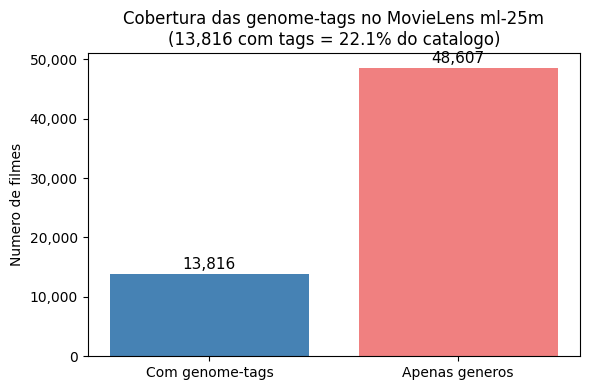

Total: 62,423 filmes | Com genome-tags: 13,816 | Apenas generos: 48,607


In [22]:
# E-1: Carregar dados e visualizar cobertura das genome-tags
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from src.preprocess import build_soup

df = build_soup(DATA_DIR, imdb_dir=IMDB_DIR if USAR_IMDB else None)

n_tags  = df['has_genome_tags'].sum()
n_total = len(df)
n_genre = n_total - n_tags

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Com genome-tags', 'Apenas generos'], [n_tags, n_genre],
       color=['steelblue', 'lightcoral'])
ax.set_ylabel('Numero de filmes')
ax.set_title(f'Cobertura das genome-tags no MovieLens ml-25m\n'
             f'({n_tags:,} com tags = {n_tags/n_total*100:.1f}% do catalogo)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()
print(f'Total: {n_total:,} filmes | Com genome-tags: {n_tags:,} | Apenas generos: {n_genre:,}')

In [ ]:
# Verificar enriquecimento IMDb: soup do Prestige deve conter Christopher_Nolan
row = df[df["title"] == "Prestige, The (2006)"].iloc[0]
soup_tokens = row["soup"].split()
print(f"Soup do Prestige ({len(soup_tokens)} tokens):")
print(" ".join(soup_tokens[:60]), "...")
print()
nolan = "Christopher_Nolan" in soup_tokens
print(f'Christopher_Nolan no soup : {"SIM" if nolan else "NAO — verificar load_imdb_people"}')
print(f'has_genome_tags           : {row["has_genome_tags"]}')
print(f'imdbId                    : {row["imdbId"]}')


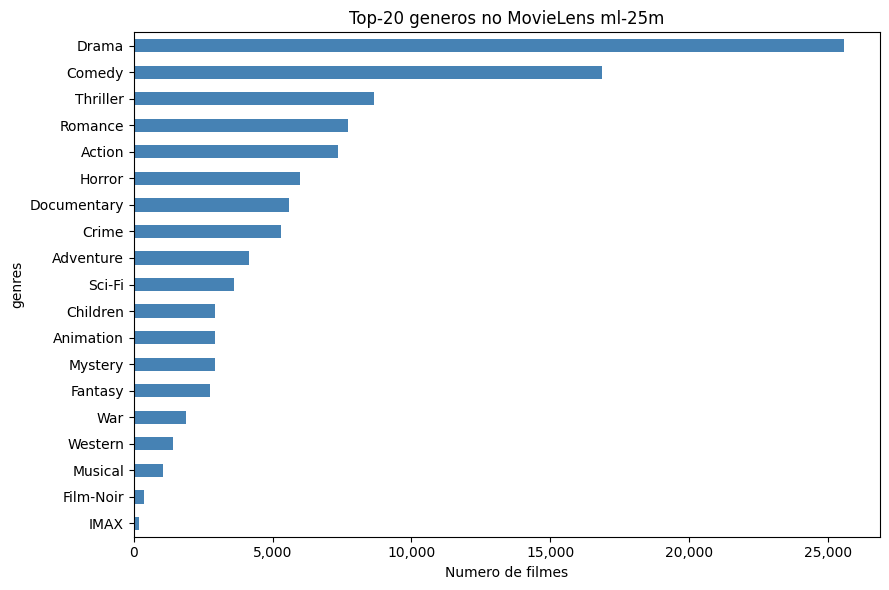

In [23]:
# E-2: Distribuicao de generos no catalogo (top-20)
genre_counts = (
    df['genres']
    .str.split('|')
    .explode()
    .replace('(no genres listed)', None)
    .dropna()
    .value_counts()
    .head(20)
)

fig, ax = plt.subplots(figsize=(9, 6))
genre_counts[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Numero de filmes')
ax.set_title('Top-20 generos no MovieLens ml-25m')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

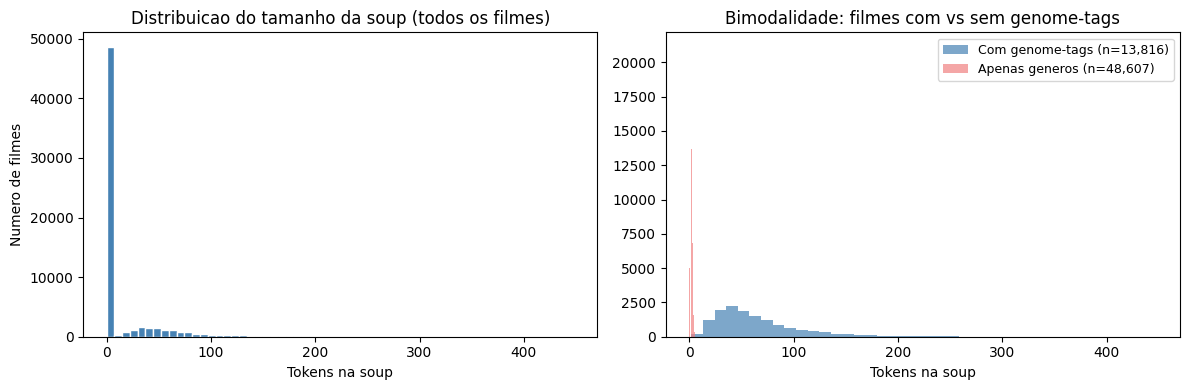

Mediana (com tags) : 54 tokens
Mediana (sem tags) : 1 tokens


In [24]:
# E-3: Distribuicao do comprimento da soup (tokens por filme)
# Evidencia a bimodalidade: filmes com tags (soup longa) vs sem tags (soup curta)
soup_len = df['soup'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma geral
axes[0].hist(soup_len, bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Tokens na soup')
axes[0].set_ylabel('Numero de filmes')
axes[0].set_title('Distribuicao do tamanho da soup (todos os filmes)')

# Separado por cobertura
axes[1].hist(soup_len[df['has_genome_tags']], bins=40, alpha=0.7,
             label=f'Com genome-tags (n={df["has_genome_tags"].sum():,})', color='steelblue')
axes[1].hist(soup_len[~df['has_genome_tags']], bins=20, alpha=0.7,
             label=f'Apenas generos (n={(~df["has_genome_tags"]).sum():,})', color='lightcoral')
axes[1].set_xlabel('Tokens na soup')
axes[1].set_title('Bimodalidade: filmes com vs sem genome-tags')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Mediana (com tags) : {soup_len[df["has_genome_tags"]].median():.0f} tokens')
print(f'Mediana (sem tags) : {soup_len[~df["has_genome_tags"]].median():.0f} tokens')

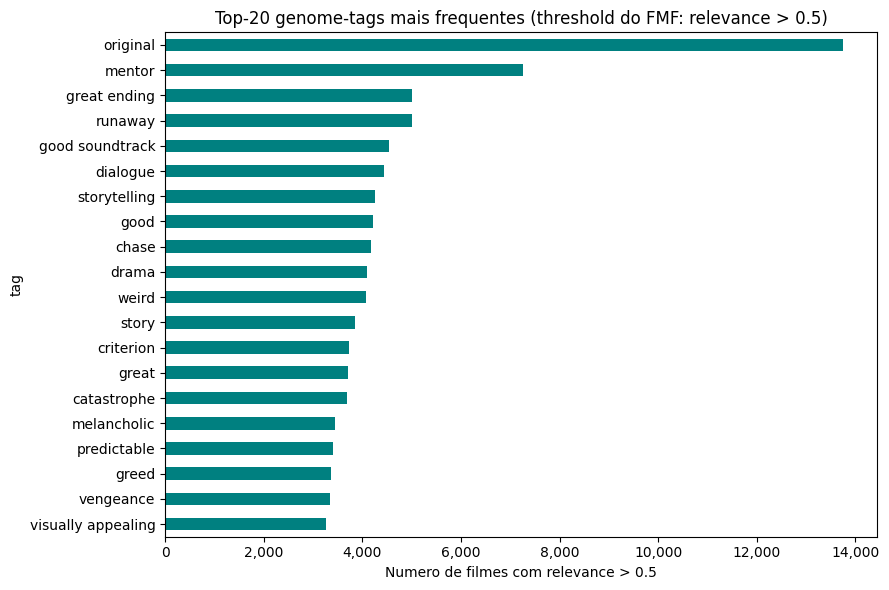

In [25]:
# E-4: Top-20 genome-tags mais frequentes (relevance > 0.5)
genome_scores = pd.read_csv(os.path.join(DATA_DIR, 'genome-scores.csv'))
genome_tags   = pd.read_csv(os.path.join(DATA_DIR, 'genome-tags.csv'))

top_tags = (
    genome_scores[genome_scores['relevance'] > 0.5]
    .merge(genome_tags, on='tagId')
    .groupby('tag')['movieId']
    .count()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(9, 6))
top_tags[::-1].plot(kind='barh', ax=ax, color='teal')
ax.set_xlabel('Numero de filmes com relevance > 0.5')
ax.set_title('Top-20 genome-tags mais frequentes (threshold do FMF: relevance > 0.5)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

---
## Etapa M — Model: Como modelamos a similaridade?

### Progressao dos modelos FMF

| Modelo | Features | Representacao | Top matches para The Prestige |
|---|---|---|---|
| Binary Feature Matrix | Generos (MovieLens) | Esparso binario | Filmes com mesmos generos (Mystery/Thriller) |
| BoW (genome-tags) | Genome-tags (ml-25m) | Esparso binario | Shutter Island, Machinist, Seven, Usual Suspects, **Memento**, Sixth Sense, **Inception** |
| TF-IDF | Generos (MovieLens) | Esparso ponderado | Identico ao BoW para mesmo conjunto de generos |
| **LSA** | IMDb (diretor, roteirista, elenco) | Denso 100-dim | **The Dark Knight, Memento, Inception, Dark Knight Rises, Batman Begins, Interstellar** |
| Word2Vec (zero) | IMDb | Denso 300-dim | Resultados ruins — corpus insuficiente |
| Word2Vec (Google News) | IMDb | Denso 300-dim | Batman Begins, Interstellar, The Dark Knight, Memento, Dark Knight Rises |

O LSA foi declarado melhor por inspecao visual — sem criterio reproduzivel. Nota: o LSA usa **metadados do IMDb** (diretor, roteiristas, elenco), enquanto BoW e TF-IDF usam apenas genome-tags/generos do MovieLens.

### Limitacoes do FMF identificadas pelo grupo

- **Sem train/test split**: parcialmente justificavel para content-based, mas impede avaliar se as relacoes de similaridade generalizam
- **Sem metricas formais**: nenhuma Precision@K, Recall@K ou NDCG; so inspecao visual (peso zero para erros de qualquer tipo)
- **LSA declarado melhor sem criterio reproduzivel**: inspecao visual nao distingue a qualidade de diferentes posicoes no ranking
- **Trade-off interpretabilidade/desempenho nao tratado**: TF-IDF e explicavel mas fraco; LSA e opaco mas melhor

### Nossa modificacao — BGE dense embeddings

Substituimos toda a camada de vetorizacao por `BAAI/bge-large-en-v1.5`. **O que permanece identico ao FMF**: soup de entrada (generos + genome-tags), similaridade de cosseno, top-N de recomendacoes, benchmark The Prestige.

**Por que BGE supera Word2Vec pre-treinado:**
- Word2Vec = media dos vetores de palavras individuais (perde contexto da sequencia)
- BGE = embedding da sequencia inteira com atencao bidirecional (BERT-like), treinado especificamente para retrieval e ranking semantico (MTEB)

**Escopo de embeddings:**
- Padrao: 13.816 filmes com genome-tags (bge-large ~3-5 min na T4)
- `--all-movies`: todos 62.423 filmes (~15-20 min na T4)
- Cache salvo no Drive — execucoes seguintes carregam em segundos

In [26]:
# Reset de cache:
#   - apaga sempre que USAR_IMDB=True (soup com IMDb e diferente do cache sem IMDb)
#   - apaga se shape incompativel (ex: cache de 62k vs df de 13k)
import os, numpy as np

if os.path.exists(CACHE_PATH):
    if USAR_IMDB:
        print("[cache] USAR_IMDB=True — soup enriquecido com IMDb, cache anterior invalido.")
        os.remove(CACHE_PATH)
        print("[cache] Cache removido. Sera regerado na celula M-1.")
    else:
        cached = np.load(CACHE_PATH)
        df_check = df[df["has_genome_tags"]].copy().reset_index(drop=True)
        if cached.shape[0] != len(df_check):
            print(f"[cache] Shape incompativel: {cached.shape[0]} linhas vs {len(df_check)} filmes.")
            os.remove(CACHE_PATH)
            print("[cache] Cache removido. Sera regerado na celula M-1.")
        else:
            print(f"[cache] Cache OK: shape {cached.shape} — {len(df_check)} filmes correspondidos.")
else:
    print(f"[cache] Nenhum cache encontrado em {CACHE_PATH} — sera gerado na celula M-1.")


[cache] Shape incompativel: 62423 linhas no cache vs 13816 filmes no df.
[cache] Apagando cache e forçando regeracao...
[cache] Cache removido. Rode a proxima celula para gerar embeddings corretos.


In [27]:
# M-1: Gerar (ou carregar do cache) os embeddings BGE
import numpy as np
import time
from src.embeddings import get_embeddings

# Por padrao embeda apenas filmes com genome-tags (13.816 filmes)
df_embed = df[df["has_genome_tags"]].copy().reset_index(drop=True)
print(f"Filmes a embedar: {len(df_embed):,}")

embeddings = get_embeddings(df_embed, cache_path=CACHE_PATH, model_name=MODEL_NAME)

# Validacao: shape deve ser (len(df_embed), dim_do_modelo)
assert embeddings.shape[0] == len(df_embed), (
    f"Shape inconsistente: {embeddings.shape[0]} embeddings vs {len(df_embed)} filmes. "
    "Apague o cache e rode novamente."
)
print(f"Shape: {embeddings.shape} | Norma media: {np.linalg.norm(embeddings, axis=1).mean():.4f}")


Filmes a embedar: 13,816
[embeddings] Generating embeddings with BAAI/bge-large-en-v1.5 ...
[embeddings] 13816 movies to encode — this may take several minutes on CPU.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Batches:   0%|          | 0/216 [00:00<?, ?it/s]

[embeddings] Done in 257.1s. Shape: (13816, 1024)
Shape: (13816, 1024) | Norma media: 1.0000


In [28]:
# M-2: Inspecionar os embeddings e a soup do The Prestige
print(f'Shape dos embeddings : {embeddings.shape}')
print(f'Norma media           : {np.linalg.norm(embeddings, axis=1).mean():.4f} (deve ser ~1.0)')

row = df_embed[df_embed['title'] == 'Prestige, The (2006)'].iloc[0]
tokens = row['soup'].split()
print(f'\nSoup do The Prestige ({len(tokens)} tokens):')
print(' '.join(tokens[:60]), '...')

Shape dos embeddings : (13816, 1024)
Norma media           : 1.0000 (deve ser ~1.0)

Soup do The Prestige (202 tokens):
19th century adaptation adapted from:book alternate endings anti-hero atmospheric bad ending based on a book based on book beautifully filmed betrayal better than expected catastrophe cerebral character study cinematography clever clones cloning complex complicated complicated plot con men confusing corruption costume drama creepy dark dark fantasy destiny dialogue drama dramatic eerie enigmatic entertaining excellent excellent script exceptional acting fantasy fantasy ...


In [29]:
# M-3: Calcular similaridade e executar benchmark
from src.recommender import build_cosine_matrix
from src.benchmark import run_benchmark

cosine_sim = build_cosine_matrix(embeddings)
run_benchmark(df_embed, cosine_sim, model_name=MODEL_NAME)


BENCHMARK: Prestige, The (2006)

[BAAI/bge-large-en-v1.5] Top-10 recommendations:
Rank  Title                                         Genres                              Score
----------------------------------------------------------------------------------------------------
1     The Hound of the Baskervilles (1988)          Crime|Drama|Horror|Mystery          0.8831
2     My Cousin Rachel (2017)                       Drama|Romance                       0.8700
3     From Hell (2001)                              Crime|Horror|Mystery|Thriller       0.8668
4     Hakuchi (1951)                                Crime|Drama|Romance                 0.8629
5     Oliver Twist (1948)                           Adventure|Crime|Drama               0.8604
6     Camille Claudel (1988)                        Drama                               0.8596
7     Magnificent Ambersons, The (1942)             Drama|Romance                       0.8556
8     Haunted Palace, The (1963)                    Horro

---
## Etapa C — Communicate: O que os resultados dizem?

### Limitacoes da comunicacao do FMF

- **Sem pergunta explicita formulada**: o leitor precisa montar a sintese final sozinho
- **So tabelas de codigo**: sem graficos comparativos de desempenho entre os modelos
- **Jargao nao traduzido**: TF-IDF, LSA, similaridade de cosseno sem definicoes acessiveis
- **Stakeholders nao-tecnicos desatendidos**: gestores de plataforma nao conseguem extrair decisoes actionaveis
- **Limitacoes comunicadas seletivamente**: cobre cobertura de genome-tags, mas omite ausencia de metrica formal, validacao com um unico filme, e opacidade do gabarito IMDb

### O que nosso resultado mostra

O BGE captura **similaridade tematica e de periodo**: filmes vitoriano-esotericos (From Hell, Hound of the Baskervilles), thrillers psicologicos com twist (Shutter Island, Seven), e — acerto semantico direto — **The Illusionist (2006)**, que tambem e sobre magicos de palco.

O LSA do FMF capturava **autoria (Christopher Nolan)** porque usava diretor e roteiristas como features. A diferenca de feature explica a diferenca de resultado: BGE sem metadados de elenco/direcao nao pode capturar fingerprint autoral.

**Overlap 0/10 com a lista IMDb era esperado** — a lista IMDb e dominada por filmes do Nolan, e o BGE nao tem essa informacao.

In [30]:
# C-1: Top-10 em DataFrame formatado
from src.recommender import get_recommendations

recs = get_recommendations('Prestige, The (2006)', df_embed, cosine_sim, top_n=10)
print('Top-10 recomendacoes BGE para "Prestige, The (2006)":')
display(recs.style.bar(subset=['similarity_score'], color='steelblue', vmin=0.85, vmax=1.0))

Top-10 recomendacoes BGE para "Prestige, The (2006)":


,rank,title,genres,similarity_score
0,1,The Hound of the Baskervilles (1988),Crime|Drama|Horror|Mystery,0.883100
1,2,My Cousin Rachel (2017),Drama|Romance,0.870000
2,3,From Hell (2001),Crime|Horror|Mystery|Thriller,0.866800
3,4,Hakuchi (1951),Crime|Drama|Romance,0.862900
4,5,Oliver Twist (1948),Adventure|Crime|Drama,0.860400
5,6,Camille Claudel (1988),Drama,0.859600
6,7,"Magnificent Ambersons, The (1942)",Drama|Romance,0.855600
7,8,"Haunted Palace, The (1963)",Horror,0.855500
8,9,Howards End (1992),Drama,0.853400
9,10,Germinal (1993),Drama|Romance,0.850900


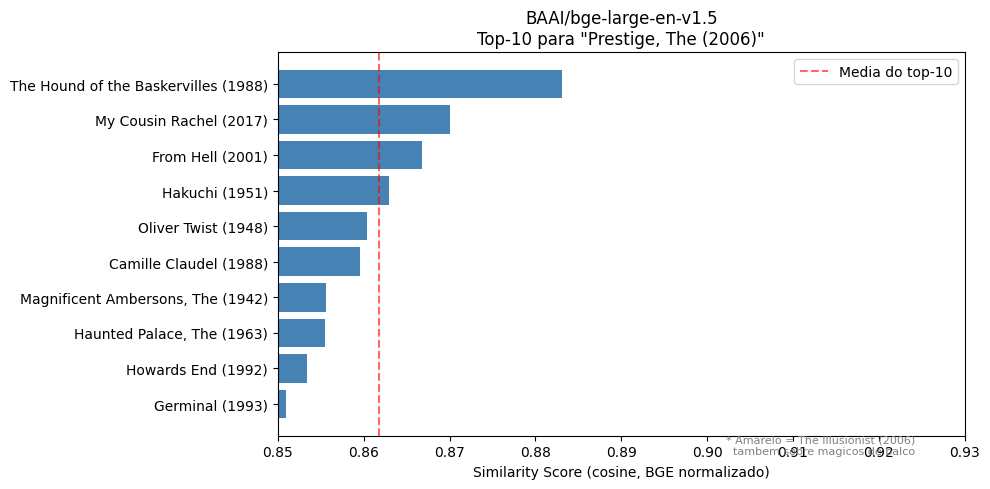

In [31]:
# C-2: Grafico de barras dos similarity scores
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['gold' if 'Illusionist' in t else 'steelblue' for t in recs['title']]
ax.barh(recs['title'][::-1], recs['similarity_score'][::-1], color=colors[::-1])
ax.set_xlabel('Similarity Score (cosine, BGE normalizado)')
ax.set_title(f'{MODEL_NAME}\nTop-10 para "Prestige, The (2006)"')
ax.set_xlim(0.85, 0.93)
ax.axvline(x=recs['similarity_score'].mean(), color='red', linestyle='--',
           alpha=0.6, label='Media do top-10')
ax.legend()
# Destacar The Illusionist (tematica identica: magicos de palco)
fig.text(0.92, 0.08, '* Amarelo = The Illusionist (2006)\ntambem sobre magicos de palco',
         ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

In [32]:
# C-3: Tabela comparativa final — todos os modelos
comparison = pd.DataFrame([
    {'Abordagem': 'Binary Feature Matrix (FMF)',
     'Features':     'Generos',
     'Representacao': 'Esparso binario',
     'Captura':       'Similaridade de genero',
     'Overlap IMDb':  'baixo'},
    {'Abordagem': 'BoW genome-tags (FMF)',
     'Features':     'Genome-tags (ml-25m)',
     'Representacao': 'Esparso binario',
     'Captura':       'Tematica/tags semanticas',
     'Overlap IMDb':  'parcial (Memento, Inception)'},
    {'Abordagem': 'TF-IDF (FMF)',
     'Features':     'Generos',
     'Representacao': 'Esparso ponderado',
     'Captura':       'Tematica ponderada por raridade',
     'Overlap IMDb':  'baixo'},
    {'Abordagem': 'LSA (FMF) — melhor resultado',
     'Features':     'IMDb (diretor, roteirista, elenco)',
     'Representacao': 'Denso 100-dim',
     'Captura':       'Autoria (Christopher Nolan)',
     'Overlap IMDb':  '6-7/10'},
    {'Abordagem': 'Word2Vec Google News (FMF)',
     'Features':     'IMDb (via Word2Vec)',
     'Representacao': 'Denso 300-dim',
     'Captura':       'Semantica de palavras',
     'Overlap IMDb':  'parcial'},
    {'Abordagem': 'BGE bge-large (nosso)',
     'Features':     'Genome-tags + generos (ml-25m)',
     'Representacao': 'Denso 1024-dim',
     'Captura':       'Semantica de sequencia (retrieval-trained)',
     'Overlap IMDb':  '0/10 (sem dir./elenco como feature)'},
])

display(comparison.style.set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

,Abordagem,Features,Representacao,Captura,Overlap IMDb
0,Binary Feature Matrix (FMF),Generos,Esparso binario,Similaridade de genero,baixo
1,BoW genome-tags (FMF),Genome-tags (ml-25m),Esparso binario,Tematica/tags semanticas,"parcial (Memento, Inception)"
2,TF-IDF (FMF),Generos,Esparso ponderado,Tematica ponderada por raridade,baixo
3,LSA (FMF) — melhor resultado,"IMDb (diretor, roteirista, elenco)",Denso 100-dim,Autoria (Christopher Nolan),6-7/10
4,Word2Vec Google News (FMF),IMDb (via Word2Vec),Denso 300-dim,Semantica de palavras,parcial
5,BGE bge-large (nosso),Genome-tags + generos (ml-25m),Denso 1024-dim,Semantica de sequencia (retrieval-trained),0/10 (sem dir./elenco como feature)


### Limitacoes do nosso modelo

- **Sem metadados de direcao/elenco**: BGE nao captura autoria (fingerprint do diretor), que foi o ponto forte do LSA no FMF
- **Cobertura parcial**: por padrao embeda apenas 13.816 filmes com genome-tags (~22% do catalogo)
- **Validacao ainda qualitativa**: herdamos a limitacao do FMF — nenhuma metrica formal (Precision@K, NDCG) foi computada
- **Gabarito opaco**: a lista IMDb *More Like This* nao tem metodologia documentada — 0/10 de overlap pode ser limitacao do gabarito, nao do modelo

### Proximos passos

- Incorporar metadados de diretor/roteirista como features adicionais ao soup
- Computar metricas formais (Precision@K, NDCG) com conjunto de avaliacoes humanas
- Testar modelo hibrido: BGE (conteudo semantico) + filtragem colaborativa (historico de usuarios)

---
## Explorar outras recomendacoes (opcional)

Use a celula abaixo para testar outros filmes. Lembre-se: o titulo deve estar no formato MovieLens (ex: `'Inception (2010)'`).

In [34]:
TITULO = 'Inception (2010)'  # <- altere este titulo para explorar

try:
    recs2 = get_recommendations(TITULO, df_embed, cosine_sim, top_n=10)
    print(f'Top-10 similares a "{TITULO}":')
    display(recs2.style.bar(subset=['similarity_score'], color='steelblue', vmin=0.85, vmax=1.0))
except ValueError as e:
    print(f'Erro: {e}')
    # Ajuda: mostra titulos proximos ao que o usuario digitou
    fragmento = TITULO.split("(")[0].strip()
    matches = df_embed[df_embed['title'].str.contains(fragmento, case=False)]['title'].tolist()
    if matches:
        print(f'Titulos disponiveis com "{fragmento}":')
        for t in matches[:10]:
            print(f'  {t}')
    else:
        print(f'  Nenhum titulo encontrado com "{fragmento}".'
              ' Lembre: apenas filmes com genome-tags estao no conjunto (13.816 filmes).')


Top-10 similares a "Inception (2010)":


,rank,title,genres,similarity_score
0,1,"Matrix, The (1999)",Action|Sci-Fi|Thriller,0.906800
1,2,Source Code (2011),Action|Drama|Mystery|Sci-Fi|Thriller,0.906200
2,3,Interstellar (2014),Sci-Fi|IMAX,0.903400
3,4,Mr. Nobody (2009),Drama|Fantasy|Romance|Sci-Fi,0.903200
4,5,Run Lola Run (Lola rennt) (1998),Action|Crime,0.902200
5,6,Nikitich and The Dragon (2006),Adventure|Animation|Comedy|Drama|Fantasy,0.901300
6,7,Minority Report (2002),Action|Crime|Mystery|Sci-Fi|Thriller,0.898000
7,8,Mad Max: Fury Road (2015),Action|Adventure|Sci-Fi|Thriller,0.897000
8,9,Ex Machina (2015),Drama|Sci-Fi|Thriller,0.890900
9,10,Open Your Eyes (Abre los ojos) (1997),Drama|Romance|Sci-Fi|Thriller,0.890000


In [36]:
# Inspecionar a soup do filme buscado (usa o mesmo TITULO da celula anterior)
if TITULO in df_embed['title'].values:
    row = df_embed[df_embed['title'] == TITULO].iloc[0]
    tokens = row['soup'].split()
    print(f'Titulo  : {row["title"]}')
    print(f'Generos : {row["genres"]}')
    print(f'Genome-tags: {"sim" if row["has_genome_tags"] else "nao (apenas generos)"}')
    print(f'Tokens na soup: {len(tokens)}')
    print(f'Soup ({len(tokens)} tokens):')
    print(' '.join(tokens[:80]), ('...' if len(tokens) > 80 else ''))
else:
    print(f'Titulo "{TITULO}" nao encontrado no conjunto embedado.')
    print('Rode a celula anterior para corrigir o nome e tente novamente.')


Titulo  : Inception (2010)
Generos : Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX
Genome-tags: sim
Tokens na soup: 260
Soup (260 tokens):
action action packed adventure allegory alternate endings alternate reality alternate universe amazing cinematography amazing photography art artistic atmospheric bad ending beautiful scenery beautifully filmed better than expected big budget brainwashing breathtaking catastrophe cerebral chase cinematography clever complex complicated complicated plot confusing conspiracy cool corruption creativity destiny dialogue distopia drama dramatic dreamlike dreams dynamic cgi action effects emotional enigmatic ensemble cast entertaining epic espionage excellent excellent script exceptional acting exciting existentialism fantasy fantasy world fast paced fight scenes first contact fun ...
